In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv

# Carica le variabili dal file .env
load_dotenv()

password = quote_plus(os.getenv("DB_PASSWORD"))
user     = os.getenv("DB_USER")
host     = os.getenv("DB_HOST")
db       = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+mysqlconnector://{user}:{password}@{host}/{db}"
)

print("✅ Connessione stabilita")

✅ Connessione stabilita


In [7]:
# ── Analisi metodi di pagamento ──────────────────────────────

query_payments = """
SELECT
    payment_type,
    COUNT(*)                     AS numero_transazioni,
    ROUND(AVG(payment_value), 2) AS valore_medio,
    ROUND(SUM(payment_value), 2) AS valore_totale
FROM order_payments
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY valore_totale DESC
"""

df_payments = pd.read_sql(query_payments, engine)
df_payments

,payment_type,numero_transazioni,valore_medio,valore_totale
0,credit_card,76795,163.32,12542084.19
1,boleto,19784,145.03,2869361.27
2,voucher,5775,65.70,379436.87
3,debit_card,1529,142.57,217989.79


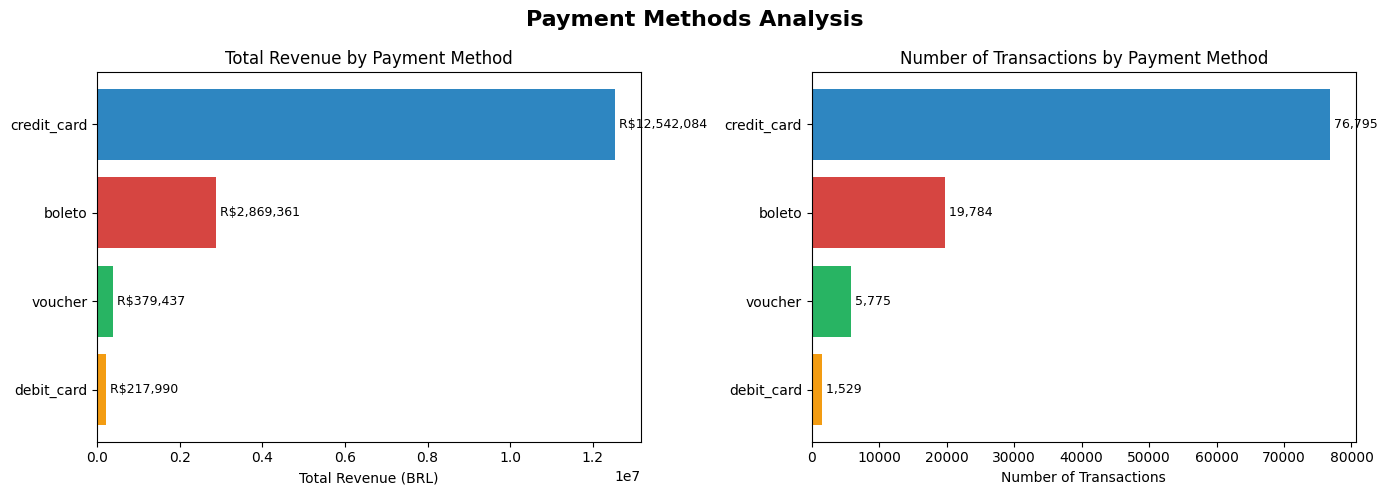

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Payment Methods Analysis", fontsize=16, fontweight="bold")

# ── Grafico 1 — Fatturato totale per metodo ──────────────────
axes[0].barh(
    df_payments["payment_type"],
    df_payments["valore_totale"],
    color=["#2E86C1", "#D64541", "#28B463", "#F39C12"]
)
axes[0].set_title("Total Revenue by Payment Method")
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].invert_yaxis()

# Aggiunge i valori sulle barre
for i, v in enumerate(df_payments["valore_totale"]):
    axes[0].text(v, i, f" R${v:,.0f}", va="center", fontsize=9)

# ── Grafico 2 — Numero transazioni per metodo ────────────────
axes[1].barh(
    df_payments["payment_type"],
    df_payments["numero_transazioni"],
    color=["#2E86C1", "#D64541", "#28B463", "#F39C12"]
)
axes[1].set_title("Number of Transactions by Payment Method")
axes[1].set_xlabel("Number of Transactions")
axes[1].invert_yaxis()

for i, v in enumerate(df_payments["numero_transazioni"]):
    axes[1].text(v, i, f" {v:,}", va="center", fontsize=9)

plt.tight_layout()
#plt.savefig("output/payments_analysis.png", dpi=150, bbox_inches="tight")
plt.show()